In [2]:
import wave
import numpy as np
import pandas as pd
from pathlib import Path
import os

## CONFIGURATION

In [3]:
AUDIO_CONFIG = {
    "sample_rate": 16000,     # Hz (WAJIB)
    "channels": 1,            # mono
    "bit_depth": 16,          # PCM 16-bit
    "dtype": "int16",         # Python: np.int16
    "duration": 1.0,          # detik
    "samples": 16000          # sample (1 detik)
}

## LOAD DATA WITH FORMAT ANDROID / ESP32 STYLE

#### 1.LOAD Wav to competible with android and microcontroler style

PCM itu singkatan dari Pulse Code Modulation.
Secara simpel:

🎧 PCM = cara menyimpan suara sebagai angka digital (raw audio)

| Bit depth | sampwidth | Range            |
| --------- | --------- | ---------------- |
| 16-bit    | 2         | -32768 s/d 32767 |
| 32-bit    | 4         | jauh lebih besar |


In [4]:
def load_wav_pcm(file_path):
    with wave.open(file_path,'rb') as wf:
        fr = wf.getframerate()
        n_channels = wf.getnchannels()
        sampwidth = wf.getsampwidth()  # this sample width example 16 = pcm 16 bit 32 pcm 32 bit
        samp_condtion = 2
        dtype = np.int16
        
        if AUDIO_CONFIG["bit_depth"] == 16000:
            samp_condtion = 2
            dtype = np.int16
        if AUDIO_CONFIG["bit_depth"] == 32000:
            samp_condtion = 4
            dtype = np.int64
            
        audio = None;    
        if sampwidth == samp_condtion and fr == AUDIO_CONFIG["sample_rate"]:
            frames = wf.readframes(fr)
            audio = np.frombuffer(frames,dtype=dtype)
            if n_channels != AUDIO_CONFIG["channels"]:
                audio = audio.reshape(-1, 2).mean(axis=1).astype(np.int16)
    return audio, fr

# testing logic loaad waav pcm
load_wav_pcm("dataset/wakeword/peto/peto_0.wav")        

(array([  56,  415,  166, ..., -387, 1164,    0],
       shape=(16000,), dtype=int16),
 16000)

### 2. LOAD dataset menggunakaan logic load_wav_pcm

Logic ini untuk mendapatkan frame dan audio raw binary
yang mana data tersebut akan di gunakan untuk normalisasi dan lain2
dan export data audio ke csv agar mudah untuk di gunaakaan kembaali

In [17]:
def load_file_wav_in_folder(file_path:str):
    paths = list(Path(file_path).rglob("*.wav"))
    raw_sample = []
    for path in paths:
        path_uniq = path.as_posix()
        audio, fr = load_wav_pcm(path_uniq)
        if audio is not None:
            print(f"processing audio {path_uniq}")
            raw_sample.append(audio)
    return raw_sample

In [18]:
wakeword_path = "dataset/wakeword"
non_wakeword_path = "dataset/non_wakeword"

wakeword_data = load_file_wav_in_folder(wakeword_path)
non_wakeword_data = load_file_wav_in_folder(non_wakeword_path)
wakeword_data,non_wakeword_data

processing audio dataset/wakeword/peto/peto_0.wav
processing audio dataset/wakeword/peto/peto_1.wav
processing audio dataset/wakeword/peto/peto_10.wav
processing audio dataset/wakeword/peto/peto_100.wav
processing audio dataset/wakeword/peto/peto_101.wav
processing audio dataset/wakeword/peto/peto_102.wav
processing audio dataset/wakeword/peto/peto_103.wav
processing audio dataset/wakeword/peto/peto_104.wav
processing audio dataset/wakeword/peto/peto_105.wav
processing audio dataset/wakeword/peto/peto_106.wav
processing audio dataset/wakeword/peto/peto_107.wav
processing audio dataset/wakeword/peto/peto_108.wav
processing audio dataset/wakeword/peto/peto_109.wav
processing audio dataset/wakeword/peto/peto_11.wav
processing audio dataset/wakeword/peto/peto_110.wav
processing audio dataset/wakeword/peto/peto_111.wav
processing audio dataset/wakeword/peto/peto_112.wav
processing audio dataset/wakeword/peto/peto_113.wav
processing audio dataset/wakeword/peto/peto_114.wav
processing audio d

([array([  56,  415,  166, ..., -387, 1164,    0],
        shape=(16000,), dtype=int16),
  array([ 719,   86, -574, ...,  -75, -586,  508],
        shape=(16000,), dtype=int16),
  array([-425, -165, -103, ...,    2, -670, -109],
        shape=(16000,), dtype=int16),
  array([0, 0, 0, ..., 0, 0, 0], shape=(16000,), dtype=int16),
  array([  77,  152,  180, ...,  212, -127,   29],
        shape=(16000,), dtype=int16),
  array([0, 0, 0, ..., 0, 0, 0], shape=(16000,), dtype=int16),
  array([0, 0, 0, ..., 0, 0, 0], shape=(16000,), dtype=int16),
  array([ 307, -208,   44, ..., -386,  477,  -53],
        shape=(16000,), dtype=int16),
  array([-1218,   112,  -476, ...,  -228,    69,   -20],
        shape=(16000,), dtype=int16),
  array([   82,  -219, -1011, ..., -1057,   -17,  -670],
        shape=(16000,), dtype=int16),
  array([ 105, -251,  899, ...,  909,  109, -739],
        shape=(16000,), dtype=int16),
  array([-439, 1180, -914, ..., -908,  301, 1180],
        shape=(16000,), dtype=int16)

In [ ]:
import tensorflow as tf

def preprocess_audio(audio):
    audio = tf.cast(audio, tf.float32) / 32768.0

    stft = tf.signal.stft(
        audio,
        frame_length=256,
        frame_step=128,
        fft_length=256
    )

    spectrogram = tf.abs(stft)

    num_spectrogram_bins = tf.shape(spectrogram)[-1]

    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=40,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=16000
    )

    mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, 1)

    log_mel = tf.math.log(mel_spectrogram + 1e-6)

    mean = tf.reduce_mean(log_mel)
    std = tf.math.reduce_std(log_mel)

    log_mel = (log_mel - mean) / (std + 1e-6)

    return log_mel


def preprocess_audio_handler(data):
    features = []

    for wk in data:
        if wk is None:
            print("FOUND NONE AUDIO")
            continue
        log_mel = preprocess_audio(wk)
        features.append(log_mel)
    return features


Audio WAV
   ↓
Preprocess (16000 Hz)
   ↓
Log-mel (80 x 100)
   ↓
Dataset (X, y)
   ↓
CNN training
   ↓
TFLite model
   ↓
Android inference (real-time mic)

In [52]:
wakeword_log_mell = preprocess_audio_handler(wakeword_data)
non_wakeword_log_mell = preprocess_audio_handler(non_wakeword_data)
wakeword_log_mell,non_wakeword_log_mell

([<tf.Tensor: shape=(124, 40), dtype=float32, numpy=
  array([[-2.06215334e+00, -1.23131132e+00, -1.02899599e+00, ...,
          -2.73718953e-01, -4.32721861e-02,  1.57857567e-01],
         [-1.61834729e+00, -7.87493825e-01, -7.59634852e-01, ...,
          -1.77353267e-02, -3.08686405e-01, -3.60325038e-01],
         [-3.62618780e+00, -2.79554558e+00, -1.95498776e+00, ...,
          -3.32940280e-01, -1.08131029e-01, -6.73502505e-01],
         ...,
         [-1.37825418e+00, -5.47397256e-01, -1.14023268e+00, ...,
          -8.99401028e-03, -1.93542670e-02,  9.86842364e-02],
         [-1.70687211e+00, -8.76020491e-01, -1.27067065e+00, ...,
          -1.58061981e-01, -3.40578794e-01, -2.15708345e-01],
         [-2.59365845e+00, -1.76284409e+00, -1.51227129e+00, ...,
           1.65550655e-03, -4.62477446e-01,  1.12645395e-01]],
        shape=(124, 40), dtype=float32)>,
  <tf.Tensor: shape=(124, 40), dtype=float32, numpy=
  array([[-2.0979855 , -1.2894222 , -1.153944  , ...,  0.13743222,
  

# prepaaare traaaining

In [58]:

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences


X_wake = pad_sequences(wakeword_log_mell, padding='post', dtype='float32')
X_non = pad_sequences(non_wakeword_log_mell, padding='post', dtype='float32')

X = np.concatenate([X_wake, X_non], axis=0)
y = np.concatenate([
    np.ones(len(wakeword_log_mell)),   # 1 = wakeword
    np.zeros(len(non_wakeword_log_mell))  # 0 = non-wakeword
])



X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

In [63]:
X_train.shape,X_val.shape

((9208, 124, 40, 1), (2303, 124, 40, 1))

In [70]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(124, 40, 1)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("models/wakeword.tflite", "wb") as f:
    f.write(tflite_model)

Epoch 1/50


c:\Program Files\miniconda\envs\machine-learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9786 - loss: 0.0630 - val_accuracy: 0.9978 - val_loss: 0.0117
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9948 - loss: 0.0205 - val_accuracy: 0.9983 - val_loss: 0.0076
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9961 - loss: 0.0151 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9986 - loss: 0.0072 - val_accuracy: 0.9991 - val_loss: 0.0016
Epoch 5/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9978 - loss: 0.0087 - val_accuracy: 0.9983 - val_loss: 0.0033
Epoch 6/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9989 - loss: 0.0064 - val_accuracy: 0.9983 - val_loss: 0.0029
Epoch 7/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9991 - loss: 0.0066 - val_accuracy: 0.9996 - val_loss: 8.5128e-04
Epoch 8/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 0

INFO:tensorflow:Assets written to: C:\Users\muham\AppData\Local\Temp\tmpot82axqi\assets


Saved artifact at 'C:\Users\muham\AppData\Local\Temp\tmpot82axqi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 124, 40, 1), dtype=tf.float32, name='keras_tensor_90')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1301298591888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1299164495696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1309274877072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1301677118416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1301677120912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1301677116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1301677116880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1301677117264: TensorSpec(shape=(), dtype=tf.resource, name=None)


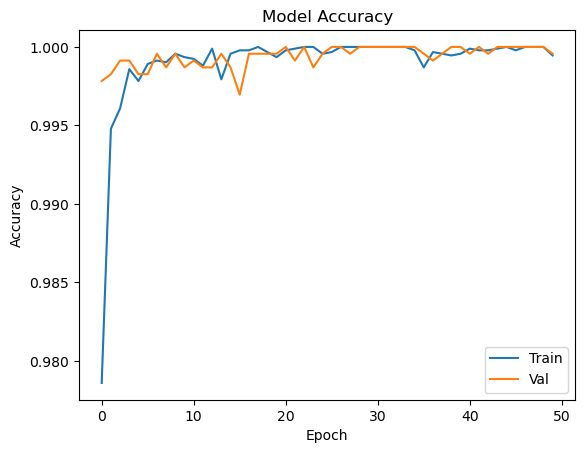

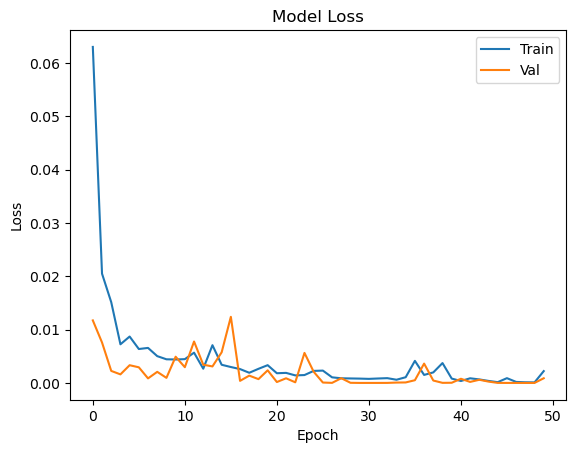

In [71]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'])
plt.show()

## TESTING

In [73]:
interpreter = tf.lite.Interpreter(model_path="models/wakeword.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_keras_tensor_90:0', 'index': 0, 'shape': array([  1, 124,  40,   1], dtype=int32), 'shape_signature': array([ -1, 124,  40,   1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 22, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [106]:
def predict_wakeword(sample):
    # sample shape harus (124, 40, 1)
    
    sample = np.expand_dims(sample, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    return output[0][0]

In [110]:

for x in X_val:
    score = predict_wakeword(x)
    print("Wakeword score:", score)

Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 2.571888e-32
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 4.3926336e-19
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 5.6673018e-33
Wakeword score: 3.5824345e-31
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 3.3517133e-17
Wakeword score: 0.0
Wakeword score: 5.595191e-25
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 5.7474136e-28
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 1.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword score: 0.0
Wakeword sco

In [143]:
def predict_from_wav(file_path):
    audio, sr = load_wav_pcm(file_path)

    sample = preprocess_audio(audio)
    # force shape correctness
    sample = np.array(sample, dtype=np.float32)
    if len(sample.shape) == 2:
        sample = sample[..., np.newaxis]  # (124,40,1)

    print("INPUT TO MODEL:", sample.shape)
    output = predict_wakeword(sample)

    print("Raw output:", output)
    return output

    

In [152]:
score = predict_from_wav("dataset/wakeword/peto/peto_2.wav")
score

INPUT TO MODEL: (124, 40, 1)
Raw output: 1.0


np.float32(1.0)

In [147]:
score = predict_from_wav("dataset/non_wakeword/_background_noise_/doing_the_dishes.wav")
score

INPUT TO MODEL: (124, 40, 1)
Raw output: 0.0


np.float32(0.0)